In [24]:
import h5py
import torch
from torch import nn
import numpy as np
from torch.nn import functional as F

import matplotlib.pyplot as plt

from torch.utils.tensorboard import SummaryWriter

In [25]:
f = h5py.File('/data/billault/round1_ts.h5')

In [26]:
f['ZE']

<HDF5 dataset "ZE": shape (85858494, 2), type "<f4">

In [27]:
ze = f['ZE'][:100000]
SW = f['SW'][:100000]
MDV = f['MDV'][:100000]

Set up target vector

In [28]:
# %%timeit
SW = f['spectrum_W_256'][:100000:,:]#:500000]
SX = f['spectrum_X_256'][:100000:,:]#:500000]

In [29]:
SSW = torch.from_numpy(SW)
SSX = torch.from_numpy(SX)

Set up target

In [30]:
target_variables = ['a_mass_size', 'alpha_area_size', 'aspect_ratio', 'b_mass_size', 'beta_area_size', 'dmean', 'lwc', 'noise_level_W', 'noise_level_X','windW','windX']

target_vector = torch.empty(SSW.shape[0],len(target_variables)+2)
for i, key in enumerate(target_variables):
    target_vector[:,i] = torch.from_numpy(f[key][:100000])
    


In [31]:
target_vector[:,-2] = torch.from_numpy(f['SIGMA_TURB'][:100000,1])
target_vector[:,-1] = torch.from_numpy(f['SIGMA_TURB'][:100000,0])

In [32]:
f.close()

In [33]:
mean = torch.mean(target_vector,axis=0)
std = torch.std(target_vector,axis=0)

In [34]:
target_vector = (target_vector-mean)/std

In [35]:
SmeanW = SSW.mean()
SstdW = SSW.std()
SmeanX = SSX.mean()
SstdX = SSX.std()

In [36]:
SSW = (SSW-SmeanW)/SstdW
SSX = (SSX-SmeanX)/SstdX
# SS[:,1,:] = (SS[:,1,:]-Smean[1])/Sstd[1]

In [37]:
randperm = torch.randperm(target_vector.size(0))
shuffled = target_vector[randperm,:]
SW_shuffled = SSW[randperm,:]
SX_shuffled = SSX[randperm,:]

In [38]:
SSW = SW_shuffled
SSX = SX_shuffled
SS = torch.stack((SSW,SSX),axis=1)

In [39]:
SS.shape

torch.Size([100000, 2, 256])

In [40]:
a = torch.max(SSW[:10000],axis=-1)

In [41]:
a.values.shape

torch.Size([10000])

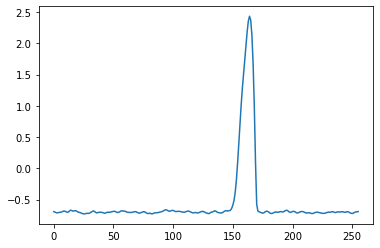

In [42]:
plt.plot(SSW[0,:])

### Set up model

In [43]:
class ResBlock(nn.Module):
    def __init__(self, nb_channels, kernel_size, padding_size, batch_normalization=True):
        super().__init__()
        self.batch_normalization = batch_normalization
        self.conv1 = nn.Conv1d(nb_channels, nb_channels,
                               kernel_size = kernel_size,
                               padding = padding_size, padding_mode='replicate')
        
        self.bn1 = nn.BatchNorm1d(nb_channels)

        self.conv2 = nn.Conv1d(nb_channels, nb_channels,
                               kernel_size = kernel_size,
                               padding = padding_size, padding_mode='replicate')

        self.bn2 = nn.BatchNorm1d(nb_channels)

    def forward(self, x):
        y = self.conv1(x)
        if self.batch_normalization:
            y = self.bn1(y)
        y = F.relu(y)
        y = self.conv2(y)
        if self.batch_normalization:
            y = self.bn2(y)
        y = y + x

        return y    
    
class Direct_w_Resblock(nn.Module):
        
    def __init__(self,nb_channels):
        super().__init__()
#         self.encoder = nn.Sequential(
        self.conv1 = nn.Conv1d(2,nb_channels,kernel_size=7)
#             nn.ReLU()
            
        self.resblock1 = ResBlock(nb_channels,kernel_size=7, padding_size=3)
        self.avgpool1 = nn.AvgPool1d(kernel_size=3, stride = 3)
#             nn.ReLU(),
            
        self.resblock2 = ResBlock(nb_channels,kernel_size=7, padding_size=3)
        self.avgpool2 = nn.AvgPool1d(kernel_size=3, stride = 3)
#             nn.ReLU(),
            
        self.resblock3 = ResBlock(nb_channels,kernel_size=7, padding_size=3)
        self.avgpool3 = nn.AvgPool1d(kernel_size=2, stride = 2)
#             nn.ReLU(),
            
        self.resblock4 = ResBlock(nb_channels,kernel_size=7, padding_size=3)
#         nn.ReLU(),
            
        self.conv2 = nn.Conv1d(nb_channels, 1, kernel_size=3, padding = 1, padding_mode='replicate')
        
    def encode(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        print('conv1', x.shape)
        x = self.resblock1(x)
        print('resblock1', x.shape)
        x = self.avgpool1(x)
        print('avgpool1', x.shape)
        x = F.relu(x)
        x = self.resblock2(x)
        print('resblock2', x.shape)
        x = self.avgpool2(x)
        print('avgpool2', x.shape)
        x = F.relu(x)
        x = self.resblock3(x)
        print('resblock3', x.shape)
        x = self.avgpool3(x)
        print('avgpool3', x.shape)
        x = F.relu(x)
        x = self.resblock4(x)
        print('resblock4', x.shape)
        x = F.relu(x)
        x = self.conv2(x)
        print('conv2', x.shape)
        return x
    
    
class Direct_w_Resblock_seq(nn.Module):
        
    def __init__(self,nb_channels):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv1d(2,nb_channels,kernel_size=7),
            nn.ReLU(),
            
            ResBlock(nb_channels,kernel_size=7, padding_size=3),
            nn.AvgPool1d(kernel_size=3, stride = 3),
            nn.ReLU(),
            
            ResBlock(nb_channels,kernel_size=7, padding_size=3),
            nn.AvgPool1d(kernel_size=3, stride = 3),
            nn.ReLU(),
            
            ResBlock(nb_channels,kernel_size=7, padding_size=3),
            nn.AvgPool1d(kernel_size=2, stride = 2),
            nn.ReLU(),
            
            ResBlock(nb_channels,kernel_size=7, padding_size=3),
            nn.ReLU(),
            
            nn.Conv1d(nb_channels, 1, kernel_size=3, padding = 1, padding_mode='replicate')
        )
        
    def forward(self, x):
        x = self.model(x)
        return x

In [49]:
model = Direct_w_Resblock_seq(30)#.to('cuda')
x = SS[:100,:,:]
model(x).shape

torch.Size([100, 1, 13])

In [45]:
x

tensor([[[-0.6933, -0.7029, -0.7108,  ..., -0.6985, -0.6968, -0.6924],
         [-0.1836, -0.1836, -0.1836,  ..., -0.1836, -0.1836, -0.1836]],

        [[-0.9414, -0.9537, -0.9684,  ..., -0.9464, -0.9419, -0.9376],
         [-0.1990, -0.1990, -0.1990,  ..., -0.1990, -0.1990, -0.1990]],

        [[-0.3677, -0.3673, -0.3655,  ..., -0.3628, -0.3631, -0.3656],
         [-1.1921, -1.1921, -1.1921,  ..., -1.1921, -1.1921, -1.1921]],

        ...,

        [[-0.9626, -0.9678, -0.9702,  ..., -0.9603, -0.9597, -0.9594],
         [-1.4645, -1.4645, -1.4645,  ..., -1.4645, -1.4645, -1.4645]],

        [[ 0.2062,  0.2074,  0.2084,  ...,  0.2009,  0.2030,  0.2049],
         [ 1.2743,  1.2743,  1.2743,  ...,  1.2743,  1.2743,  1.2743]],

        [[-1.3040, -1.3087, -1.3058,  ..., -1.2874, -1.2897, -1.2961],
         [-0.9476, -0.9476, -0.9476,  ..., -0.9476, -0.9476, -0.9476]]])

In [46]:
y = model.decode(x)
y.shape

AttributeError: 'Encoder1_w_Resblock' object has no attribute 'decode'

In [201]:

n_input_features = 9
n_hidden_units = 65
nb_channels = 30

z = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=15,stride=2,padding=5)(y)
z.shape

NameError: name 'y' is not defined

In [99]:
w = nn.ConvTranspose1d(nb_channels, 1, kernel_size=9,stride=1,padding=1)(y)
w.shape

torch.Size([250, 1, 513])

In [100]:
F.avg_pool1d(w,kernel_size=2,stride=1).shape

torch.Size([250, 1, 512])

In [24]:
writer = SummaryWriter(log_dir='test_decoder_runs/')
bc = 0
loss_list = []
epochloss_list = []
model = Decoder_X(30,65,9).to('cuda')
batch_size=250
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

In [204]:
# writer = SummaryWriter()
bc = 0
loss_list = []
epochloss_list = []
model = Decoder_X(30,25,9).to('cuda')
batch_size=250
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)# model.to('cpu').decode(input_vector)

In [205]:
for epoch in range(0,120):
    epochloss = 0
    for b in range(0, input_vector.size(0), batch_size):
        sub_input = shuffled[b:b+batch_size,:].to('cuda')
        output = model.decode(sub_input)
        target = SSW[b:b+batch_size,:].unsqueeze(1).to('cuda')
#         print(target.shape)
        loss = 0.5 * (output - target).pow(2).sum() / output.size(0)
        epochloss+=loss*output.size(0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
#         writer.add_scalar('batch_loss',loss,bc)
        bc+=1
#         if b%(25*batch_size)==0:
#             print(bc,loss)
#     writer.add_scalar('training_loss',epochloss/input_vector.size(0), epoch)
    print(epoch, epochloss/input_vector.size(0))
    epochloss_list.append(epochloss)
    loss_list.append(loss)

0 tensor(53.1294, device='cuda:0', grad_fn=<DivBackward0>)
1 tensor(41.6182, device='cuda:0', grad_fn=<DivBackward0>)
2 tensor(39.3216, device='cuda:0', grad_fn=<DivBackward0>)
3 tensor(36.0058, device='cuda:0', grad_fn=<DivBackward0>)
4 tensor(33.4066, device='cuda:0', grad_fn=<DivBackward0>)
5 tensor(31.0374, device='cuda:0', grad_fn=<DivBackward0>)
6 tensor(30.0963, device='cuda:0', grad_fn=<DivBackward0>)
7 tensor(28.5496, device='cuda:0', grad_fn=<DivBackward0>)
8 tensor(27.6958, device='cuda:0', grad_fn=<DivBackward0>)
9 tensor(26.6798, device='cuda:0', grad_fn=<DivBackward0>)
10 tensor(26.6141, device='cuda:0', grad_fn=<DivBackward0>)
11 tensor(25.7795, device='cuda:0', grad_fn=<DivBackward0>)
12 tensor(25.3066, device='cuda:0', grad_fn=<DivBackward0>)
13 tensor(24.4784, device='cuda:0', grad_fn=<DivBackward0>)
14 tensor(24.7502, device='cuda:0', grad_fn=<DivBackward0>)
15 tensor(24.3444, device='cuda:0', grad_fn=<DivBackward0>)
16 tensor(23.5903, device='cuda:0', grad_fn=<DivBa

KeyboardInterrupt: 

In [119]:
for g in optimizer.param_groups:
    g['lr'] = 1e-3
# batch_size=50

In [64]:
output.shape

torch.Size([250, 1, 256])

Text(0, 0.5, 'spectral reflectivity')

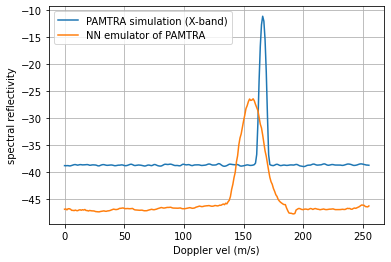

In [210]:
rvel = np.linspace(-9.9,9.9,512)

# output2 = F.avg_pool1d(output,kernel_size=2,stride=2)
plt.plot((target[47,0,:].cpu()*Sstd+Smean).detach().numpy(), label = 'PAMTRA simulation (X-band)')
plt.plot((output[47,0,:].cpu()*Sstd+Smean).detach().numpy(), label = 'NN emulator of PAMTRA')
plt.legend()
plt.grid()

plt.xlabel('Doppler vel (m/s)')
plt.ylabel('spectral reflectivity')

# plt.gcf().savefig('ex_pamtra_emulator.pdf',bbox_inches='tight')

In [81]:
ex_target = SS[-100:,0,:]
ex_input = input_vector[-100:,:]

In [82]:

ex_output = model.decode(ex_input.float().to('cuda'))

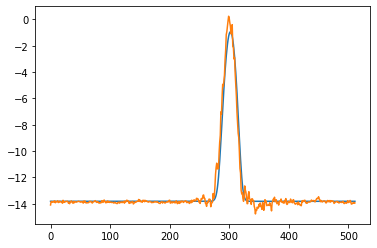

In [83]:
plt.plot((ex_target[0,:].cpu()*Sstd[0]+Smean[0]).detach().numpy())
plt.plot((ex_output[0,0,:].cpu()*Sstd[0]+Smean[0]).detach().numpy())

In [88]:
for i in range(ex_target.shape[0]):

    plt.plot((ex_target[i,:].cpu()*Sstd[0]+Smean[0]).detach().numpy(), label = 'PAMTRA simulation (X-band)')
    plt.plot((ex_output[i,0,:].cpu()*Sstd[0]+Smean[0]).detach().numpy(),  label = 'NN emulator of PAMTRA')

    plt.grid()

    plt.xlabel('Doppler vel (m/s)')
    plt.ylabel('spectral reflectivity')
    plt.legend()
    plt.gcf().savefig('ex_pamtra_emulator_test_%d.pdf'%i,bbox_inches='tight')
    plt.close()

In [48]:
SSX[0,0,:].to('cpu').detach().numpy().shape

(512,)

### Tests to replace convT with conv+interp

In [22]:
class Decoder_X2(nn.Module):
    def __init__(self,nb_channels,n_hidden_units, n_input_features):
        super().__init__()
        self.nb_channels = nb_channels
        self.fc1 = nn.Linear(n_input_features, n_hidden_units)
        self.fc2 = nn.Linear(n_hidden_units, n_hidden_units)
        self.fc3 = nn.Linear(n_hidden_units, n_hidden_units)

        self.convt4 =nn.ConvTranspose1d(1, nb_channels, kernel_size=5,stride=1,padding=0)
        self.convt3 = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=10,stride=2,padding=5)
#         self.convt2 = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=15,stride=2,padding=5)
        self.conv2 = nn.Conv1d(nb_channels, nb_channels, kernel_size=10,padding=0)
        self.conv1 = nn.Conv1d(nb_channels, nb_channels, kernel_size=15, padding=0)
    
    def decode(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        x = x.unsqueeze(1)
#         print(x.shape)
        x = F.relu(self.convt4(x))
#         print(x.shape)
        x = F.relu(self.convt3(x))
#         print(x.shape)
        x = F.interpolate(x,scale_factor=2, mode='linear')
        x = F.relu(self.conv2(x))
#         print(x.shape)
        x = F.interpolate(x,scale_factor=2, mode='linear')
        x = self.conv1(x)
        return x

In [50]:
writer = SummaryWriter()
loss_list = []
epochloss_list = []
model = Decoder_X3(30,65,9).to('cuda')
batch_size=250
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [60]:
for epoch in range(90,100):
    epochloss = 0
    for b in range(0, input_vector.size(0), batch_size):
        sub_input = shuffled[b:b+batch_size,:]
        output = model.decode(sub_input)
        target = SSX[b:b+batch_size,:,:]
#         print(target.shape)
        loss = 0.5 * (output - target).pow(2).sum() / output.size(0)
        epochloss+=loss*output.size(0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
#         if b%(5*batch_size)==0:
    writer.add_scalar('training_loss',epochloss/input_vector.size(0), epoch)
    print(epoch, loss)
    epochloss_list.append(epochloss)
    loss_list.append(loss)

90 tensor(184.7919, device='cuda:0', grad_fn=<DivBackward0>)
91 tensor(184.6342, device='cuda:0', grad_fn=<DivBackward0>)
92 tensor(184.4854, device='cuda:0', grad_fn=<DivBackward0>)
93 tensor(184.4143, device='cuda:0', grad_fn=<DivBackward0>)
94 tensor(184.3739, device='cuda:0', grad_fn=<DivBackward0>)
95 tensor(184.3100, device='cuda:0', grad_fn=<DivBackward0>)
96 tensor(184.0041, device='cuda:0', grad_fn=<DivBackward0>)
97 tensor(183.8649, device='cuda:0', grad_fn=<DivBackward0>)
98 tensor(183.7178, device='cuda:0', grad_fn=<DivBackward0>)
99 tensor(183.5650, device='cuda:0', grad_fn=<DivBackward0>)


In [59]:
for g in optimizer.param_groups:
    g['lr'] = 5e-5
batch_size=500

In [262]:
model = Decoder_X2(30,65,9)
model.decode(x).shape

torch.Size([250, 1, 65])
torch.Size([250, 30, 69])
torch.Size([250, 30, 136])
torch.Size([250, 30, 263])


torch.Size([250, 30, 512])

In [254]:
x = shuffled[0:0+batch_size,:].to('cpu')

n_input_features = 9
n_hidden_units = 65
nb_channels = 30

x = nn.Linear(n_input_features, n_hidden_units)(x)

x = nn.Linear(n_hidden_units, n_hidden_units)(x)

x = nn.Linear(n_hidden_units, n_hidden_units)(x)

x = x.unsqueeze(1)

x = nn.ConvTranspose1d(1, nb_channels, kernel_size=5,stride=1,padding=0)(x)

x.shape

x = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=10,stride=2,padding=5)(x)
x.shape

# x = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=15,stride=2,padding=5)(x)

# x.shape

y = F.interpolate(x,scale_factor=2, mode='linear')
y = nn.Conv1d(nb_channels, nb_channels, kernel_size=10,padding=0)(y)

y.shape

# nn.ConvTranspose1d(nb_channels, 1, kernel_size=7,stride=1,padding=0)(y).shape

z = F.interpolate(y,scale_factor=2, mode='linear')
nn.Conv1d(nb_channels, nb_channels, kernel_size=15, padding=0)(z).shape


Text(0, 0.5, 'spectral reflectivity')

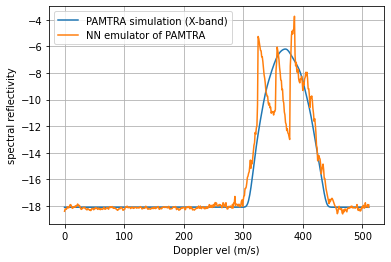

In [115]:
rvel = np.linspace(-9.9,9.9,512)
plt.plot((target[10,0,:].cpu()*Sstd[0]+Smean[0]).detach().numpy(), label = 'PAMTRA simulation (X-band)')
plt.plot((output[10,0,:].cpu()*Sstd[0]+Smean[0]).detach().numpy(), label = 'NN emulator of PAMTRA')
plt.legend()
plt.grid()

plt.xlabel('Doppler vel (m/s)')
plt.ylabel('spectral reflectivity')


In [47]:
class Decoder_X3(nn.Module):
    def __init__(self,nb_channels,n_hidden_units, n_input_features):
        super().__init__()
        self.nb_channels = nb_channels
        self.fc1 = nn.Linear(n_input_features, n_hidden_units)
        self.fc2 = nn.Linear(n_hidden_units, n_hidden_units)
        self.fc3 = nn.Linear(n_hidden_units, n_hidden_units)

        self.convt4 = nn.ConvTranspose1d(1, nb_channels, kernel_size=5,stride=1,padding=2)
        self.convt3 = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=8,stride=2,padding=4)
        self.convt2 = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=15,stride=2,padding=4)
        self.conv1 = nn.Conv1d(nb_channels, nb_channels, kernel_size=11, padding=0)
    
    def decode(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
#         print(x.shape)
        x = x.unsqueeze(1)
#         print(x.shape)
        x = F.relu(self.convt4(x))
        x = F.relu(self.convt3(x))
        x = F.relu(self.convt2(x))
        x = F.interpolate(x,scale_factor=2, mode='linear')
        x = self.conv1(x)
        return x

In [46]:
x = shuffled[0:0+batch_size,:].to('cpu')

n_input_features = 9
n_hidden_units = 65
nb_channels = 30

x = nn.Linear(n_input_features, n_hidden_units)(x)

x = nn.Linear(n_hidden_units, n_hidden_units)(x)

x = nn.Linear(n_hidden_units, n_hidden_units)(x)

x = x.unsqueeze(1)

x = nn.ConvTranspose1d(1, nb_channels, kernel_size=5,stride=1,padding=2)(x)

print(x.shape)

x = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=8,stride=2,padding=4)(x)
print(x.shape)

x = nn.ConvTranspose1d(nb_channels, nb_channels, kernel_size=15,stride=2,padding=4)(x)

print(x.shape)

# y = F.interpolate(x,scale_factor=2, mode='linear')
# y = nn.Conv1d(nb_channels, nb_channels, kernel_size=10,padding=0)(y)

# y.shape

# nn.ConvTranspose1d(nb_channels, 1, kernel_size=7,stride=1,padding=0)(y).shape

z = F.interpolate(x,scale_factor=2, mode='linear')
nn.Conv1d(nb_channels, nb_channels, kernel_size=11, padding=0)(z).shape


torch.Size([250, 30, 65])
torch.Size([250, 30, 128])
torch.Size([250, 30, 261])


torch.Size([250, 30, 512])